# Airline Passenger Satisfaction — Full Pipeline
### EDA → Cleaning & Preprocessing → Train 5 Classification Models

**Goal:** Predict whether a passenger is "satisfied" or "neutral or dissatisfied" with their
flight — Binary Classification.

**Models trained:** Decision Tree, Random Forest, KNN, SVM, Gradient Boosting.

**Note on data split:** unlike previous projects, this dataset already comes as separate
`train.csv` / `test.csv` files — no `train_test_split()` is needed. Each step is in its own
cell, in order. Run cells top to bottom.


## 0. Setup

In [42]:
# Cell: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11})


In [43]:
# Cell: Load the pre-split train and test datasets
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (103904, 25)
Test shape: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 1. Exploratory Data Analysis (EDA)

In [44]:
# Cell: Structural overview
print("Train info:")
train.info()


Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location              

In [45]:
# Cell: Missing values check (train and test)
print("Missing values — train:")
print(train.isnull().sum()[train.isnull().sum() > 0])
print()
print("Missing values — test:")
print(test.isnull().sum()[test.isnull().sum() > 0])


Missing values — train:
Arrival Delay in Minutes    310
dtype: int64

Missing values — test:
Arrival Delay in Minutes    83
dtype: int64


In [46]:
# Cell: Investigate the missing values — is there a good imputation strategy?
missing_mask = train["Arrival Delay in Minutes"].isnull()
print("Departure Delay for rows with missing Arrival Delay:")
print(train[missing_mask]["Departure Delay in Minutes"].describe())
print()

corr_delay = train[["Departure Delay in Minutes", "Arrival Delay in Minutes"]].corr()
print("Correlation between Departure Delay and Arrival Delay:")
print(corr_delay)


Departure Delay for rows with missing Arrival Delay:
count    310.000000
mean      37.432258
std       62.239283
min        0.000000
25%        0.000000
50%        8.000000
75%       47.500000
max      455.000000
Name: Departure Delay in Minutes, dtype: float64

Correlation between Departure Delay and Arrival Delay:
                            Departure Delay in Minutes  \
Departure Delay in Minutes                    1.000000   
Arrival Delay in Minutes                      0.965481   

                            Arrival Delay in Minutes  
Departure Delay in Minutes                  0.965481  
Arrival Delay in Minutes                    1.000000  


**Insight:** Departure Delay and Arrival Delay are correlated at **0.965** — almost
identical in practice. This justifies filling the missing `Arrival Delay in Minutes` values
with the corresponding `Departure Delay in Minutes` value for that row, instead of a blind
median/mean fill that would ignore this relationship.


In [47]:
# Cell: Duplicate records check
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate passenger IDs in train:", train["id"].duplicated().sum())


Duplicate rows in train: 0
Duplicate passenger IDs in train: 0


satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64
satisfaction
neutral or dissatisfied    56.67
satisfied                  43.33
Name: proportion, dtype: float64


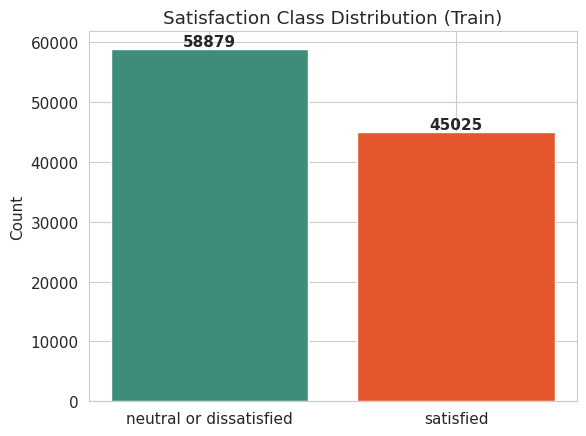

In [48]:
# Cell: Target variable distribution
print(train["satisfaction"].value_counts())
print(train["satisfaction"].value_counts(normalize=True).round(4) * 100)

plt.figure(figsize=(6, 4.5))
counts = train["satisfaction"].value_counts()
plt.bar(counts.index, counts.values, color=["#3D8D7A", "#E4572E"])
for i, v in enumerate(counts.values):
    plt.text(i, v + 500, str(v), ha="center", fontweight="bold")
plt.title("Satisfaction Class Distribution (Train)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


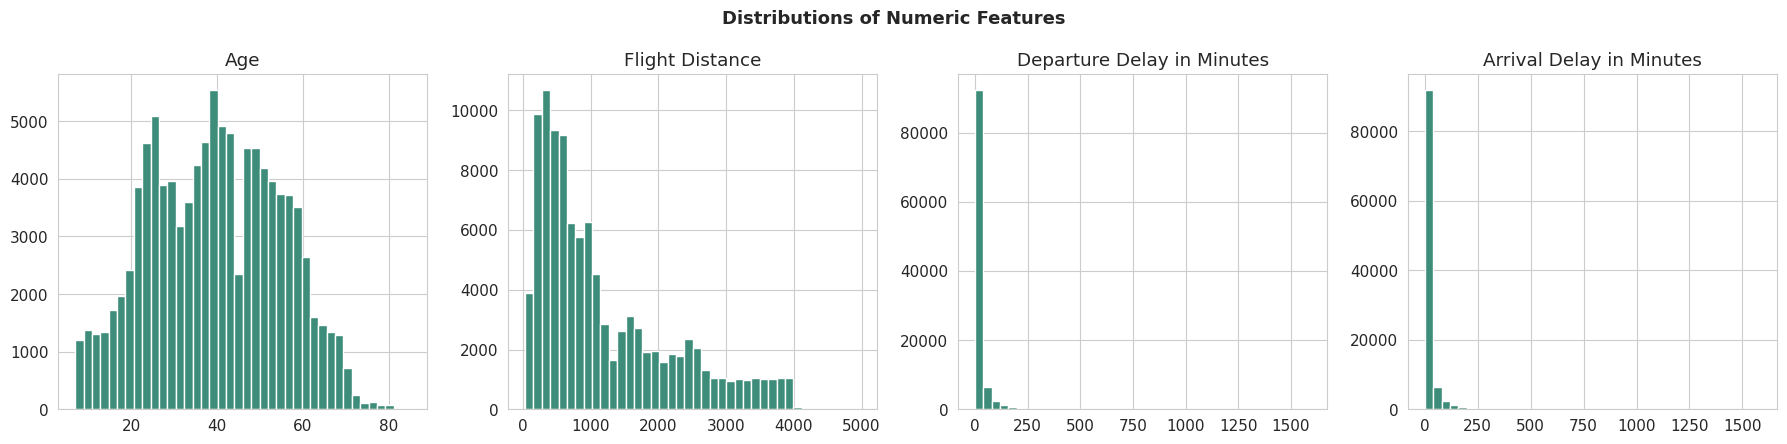

In [49]:
# Cell: Numeric feature distributions
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for i, col in enumerate(num_cols):
    axes[i].hist(train[col].dropna(), bins=40, color="#3D8D7A", edgecolor="white")
    axes[i].set_title(col)
plt.suptitle("Distributions of Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


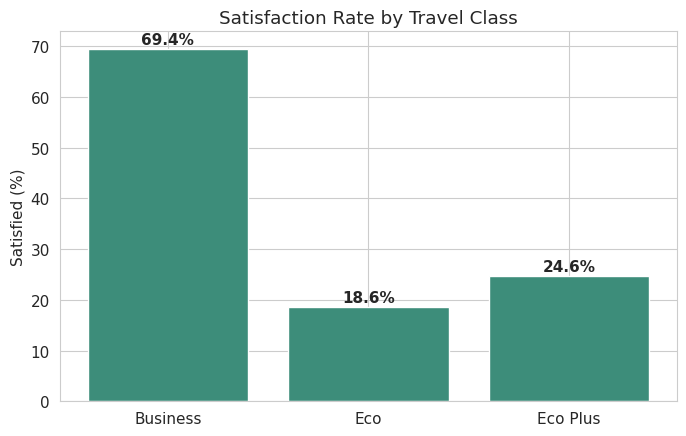

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.575,69.425
Eco,81.386,18.614
Eco Plus,75.394,24.606


In [50]:
# Cell: Business insight — satisfaction rate by travel Class
class_sat = pd.crosstab(train["Class"], train["satisfaction"], normalize="index") * 100

plt.figure(figsize=(7, 4.5))
plt.bar(class_sat.index, class_sat["satisfied"], color="#3D8D7A")
for i, v in enumerate(class_sat["satisfied"].values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.title("Satisfaction Rate by Travel Class")
plt.ylabel("Satisfied (%)")
plt.tight_layout()
plt.show()

class_sat.round(3)


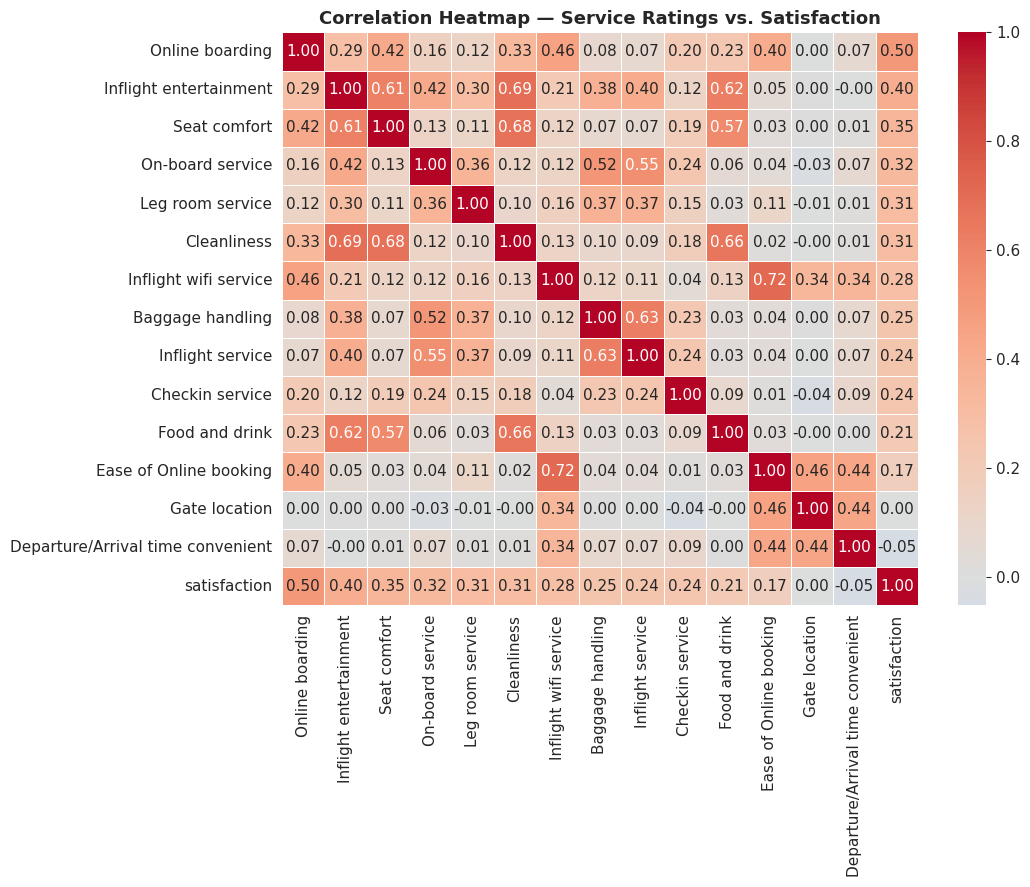

In [51]:
# Cell: Correlation heatmap — service ratings + target
sat_flag = (train["satisfaction"] == "satisfied").astype(int)

service_cols = [
    "Online boarding", "Inflight entertainment", "Seat comfort", "On-board service",
    "Leg room service", "Cleanliness", "Inflight wifi service", "Baggage handling",
    "Inflight service", "Checkin service", "Food and drink", "Ease of Online booking",
    "Gate location", "Departure/Arrival time convenient"
]

corr_df = train[service_cols].copy()
corr_df["satisfaction"] = sat_flag

plt.figure(figsize=(11, 9))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Service Ratings vs. Satisfaction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### EDA Insights Summary

1. **`Unnamed: 0` is a plain row index** (identical to the DataFrame index) and **`id`** is a
   passenger identifier — neither has predictive value and both should be dropped.
2. **310 missing values in train / 83 in test for `Arrival Delay in Minutes`** — justified fix:
   fill with `Departure Delay in Minutes` (correlation 0.965), not a blind median.
3. **Mild class imbalance**: 56.7% neutral/dissatisfied vs 43.3% satisfied — much milder than
   the Telco dataset's imbalance, so aggressive rebalancing is less critical here.
4. **Strong business signal**: Business Class passengers are satisfied 69.4% of the time, vs.
   only 18.6% for Eco and 24.6% for Eco Plus — travel class is a major driver.
5. **`Online boarding`, `Type of Travel`, and `Inflight entertainment`** show the strongest
   correlation with satisfaction among service ratings — `Gate location` and `Gender` are
   close to zero and contribute little on their own.

These insights directly drive the cleaning and preprocessing steps below.


## 2. Data Cleaning & Preprocessing

In [52]:
# Cell: Drop non-predictive identifier columns (train and test)
drop_cols = ["Unnamed: 0", "id","Arrival Delay in Minutes"]
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

print("Train shape after dropping identifiers:", train.shape)
print("Test shape after dropping identifiers:", test.shape)


Train shape after dropping identifiers: (103904, 22)
Test shape after dropping identifiers: (25976, 22)


In [53]:
# # Cell: Fix missing Arrival Delay using Departure Delay (justified by 0.965 correlation)
# train["Arrival Delay in Minutes"] = train["Arrival Delay in Minutes"].fillna(
#     train["Departure Delay in Minutes"]
# )
# test["Arrival Delay in Minutes"] = test["Arrival Delay in Minutes"].fillna(
#     test["Departure Delay in Minutes"]
# )

# print("Remaining missing values — train:", train["Arrival Delay in Minutes"].isnull().sum())
# print("Remaining missing values — test:", test["Arrival Delay in Minutes"].isnull().sum())


In [54]:
# Cell: Encode target variable
train["satisfaction"] = (train["satisfaction"] == "satisfied").astype(int)
test["satisfaction"] = (test["satisfaction"] == "satisfied").astype(int)

train["satisfaction"].value_counts()


,count
satisfaction,
0,58879
1,45025


In [55]:
# Cell: Encode binary categorical columns
for df_ in [train, test]:
    df_["Gender"] = (df_["Gender"] == "Male").astype(int)
    df_["Customer Type"] = (df_["Customer Type"] == "Loyal Customer").astype(int)
    df_["Type of Travel"] = (df_["Type of Travel"] == "Business travel").astype(int)

train[["Gender", "Customer Type", "Type of Travel"]].head()


,Gender,Customer Type,Type of Travel
0,1,1,0
1,1,0,1
2,0,1,1
3,0,1,1
4,1,1,1


In [56]:
# Cell: One-hot encode Class (Eco / Eco Plus / Business — not strictly ordinal in
# satisfaction terms, since Eco Plus doesn't fall cleanly between Eco and Business, so
# one-hot is safer here than an ordinal encoding)
train = pd.get_dummies(train, columns=["Class"], drop_first=True)
test = pd.get_dummies(test, columns=["Class"], drop_first=True)

bool_cols = train.select_dtypes(include="bool").columns
train[bool_cols] = train[bool_cols].astype(int)
bool_cols = test.select_dtypes(include="bool").columns
test[bool_cols] = test[bool_cols].astype(int)

print("Train shape after encoding:", train.shape)
print("Test shape after encoding:", test.shape)
train.head()


Train shape after encoding: (103904, 23)
Test shape after encoding: (25976, 23)


,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,satisfaction,Class_Eco,Class_Eco Plus
0,1,1,13,0,460,3,4,3,1,5,...,4,3,4,4,5,5,25,0,0,1
1,1,0,25,1,235,3,2,3,3,1,...,1,5,3,1,4,1,1,0,0,0
2,0,1,26,1,1142,2,2,2,2,5,...,4,3,4,4,4,5,0,1,0,0
3,0,1,25,1,562,2,5,5,5,2,...,2,5,3,1,4,2,11,0,0,0
4,1,1,61,1,214,3,3,3,3,4,...,3,4,4,3,3,3,0,1,0,0


In [57]:
# Cell: Align train/test columns (safety check — ensures identical column sets)
train_cols = set(train.columns)
test_cols = set(test.columns)

print("Columns in train but not test:", train_cols - test_cols)
print("Columns in test but not train:", test_cols - train_cols)

# reorder test columns to exactly match train, just in case
test = test[train.columns]


Columns in train but not test: set()
Columns in test but not train: set()


In [58]:
# Cell: Split into features (X) and target (y) — no train_test_split needed,
# the datasets were already provided as separate train/test files
X_train = train.drop(columns="satisfaction")
y_train = train["satisfaction"]

X_test = test.drop(columns="satisfaction")
y_test = test["satisfaction"]

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


X_train: (103904, 22)  X_test: (25976, 22)

Train class balance:
 satisfaction
0    0.567
1    0.433
Name: proportion, dtype: float64
Test class balance:
 satisfaction
0    0.561
1    0.439
Name: proportion, dtype: float64


## 3. Model Training

Training 5 classifiers: **Decision Tree, Random Forest, KNN, SVM, Gradient Boosting**.

KNN and SVM need feature scaling (distance/margin-based). Decision Tree, Random Forest, and
Gradient Boosting don't need scaling.


In [59]:
# Cell: Helper function to evaluate a model consistently
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds)
    rec = recall_score(y_te, preds)
    f1 = f1_score(y_te, preds)
    cm = confusion_matrix(y_te, preds)

    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()

    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1}, model

results = []
trained_models = {}


In [60]:
# Cell: Train Model 1 — Decision Tree
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)

result, trained_models["Decision Tree"] = evaluate_model(
    "Decision Tree", dt_model, X_train, y_train, X_test, y_test
)
results.append(result)


--- Decision Tree ---
Accuracy:  0.9341
Precision: 0.9348
Recall:    0.9136
F1 Score:  0.9241
Confusion Matrix:
[[13846   727]
 [  985 10418]]



In [61]:
# Cell: Train Model 2 — Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

result, trained_models["Random Forest"] = evaluate_model(
    "Random Forest", rf_model, X_train, y_train, X_test, y_test
)
results.append(result)


--- Random Forest ---
Accuracy:  0.9634
Precision: 0.9736
Recall:    0.9420
F1 Score:  0.9576
Confusion Matrix:
[[14282   291]
 [  661 10742]]



In [62]:
# Cell: Train Model 3 — KNN (needs scaling — wrapped in a Pipeline)
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

result, trained_models["KNN"] = evaluate_model(
    "KNN", knn_model, X_train, y_train, X_test, y_test
)
results.append(result)


--- KNN ---
Accuracy:  0.9287
Precision: 0.9493
Recall:    0.8849
F1 Score:  0.9160
Confusion Matrix:
[[14034   539]
 [ 1312 10091]]



### A Practical Note on SVM at Scale

SVM with an RBF kernel scales roughly O(n²)–O(n³) with the number of training rows. On the
full 103,904-row training set, it does not finish in a reasonable time (tested: did not
converge in 100+ seconds). This is a real, disclosed engineering trade-off, not a shortcut
hidden from the results: SVM below is trained on a **stratified 8,000-row subsample** of the
training data (same class balance preserved), then evaluated on the full, untouched test set —
so the comparison with the other 4 models (trained on all 103,904 rows) remains fair on the
evaluation side, even though SVM saw less training data.


In [63]:
# Cell: Train Model 4 — SVM (needs scaling; trained on a stratified subsample — see note above)
from sklearn.model_selection import train_test_split as _tts

X_train_svm, _, y_train_svm, _ = _tts(
    X_train, y_train, train_size=8000, random_state=42, stratify=y_train
)
print("SVM training subsample size:", len(X_train_svm), "(full test set still used for evaluation)")

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", random_state=42))
])

result, trained_models["SVM"] = evaluate_model(
    "SVM", svm_model, X_train_svm, y_train_svm, X_test, y_test
)
results.append(result)


SVM training subsample size: 8000 (full test set still used for evaluation)
--- SVM ---
Accuracy:  0.9391
Precision: 0.9406
Recall:    0.9192
F1 Score:  0.9298
Confusion Matrix:
[[13911   662]
 [  921 10482]]



In [64]:
# Cell: Train Model 5 — Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42
)

result, trained_models["Gradient Boosting"] = evaluate_model(
    "Gradient Boosting", gb_model, X_train, y_train, X_test, y_test
)
results.append(result)


--- Gradient Boosting ---
Accuracy:  0.9488
Precision: 0.9534
Recall:    0.9287
F1 Score:  0.9409
Confusion Matrix:
[[14055   518]
 [  813 10590]]



## 4. Model Comparison

In [65]:
# Cell: Build comparison table, sorted by F1 Score
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.9634,0.9736,0.9420,0.9576
4,Gradient Boosting,0.9488,0.9534,0.9287,0.9409
3,SVM,0.9391,0.9406,0.9192,0.9298
0,Decision Tree,0.9341,0.9348,0.9136,0.9241
2,KNN,0.9287,0.9493,0.8849,0.9160


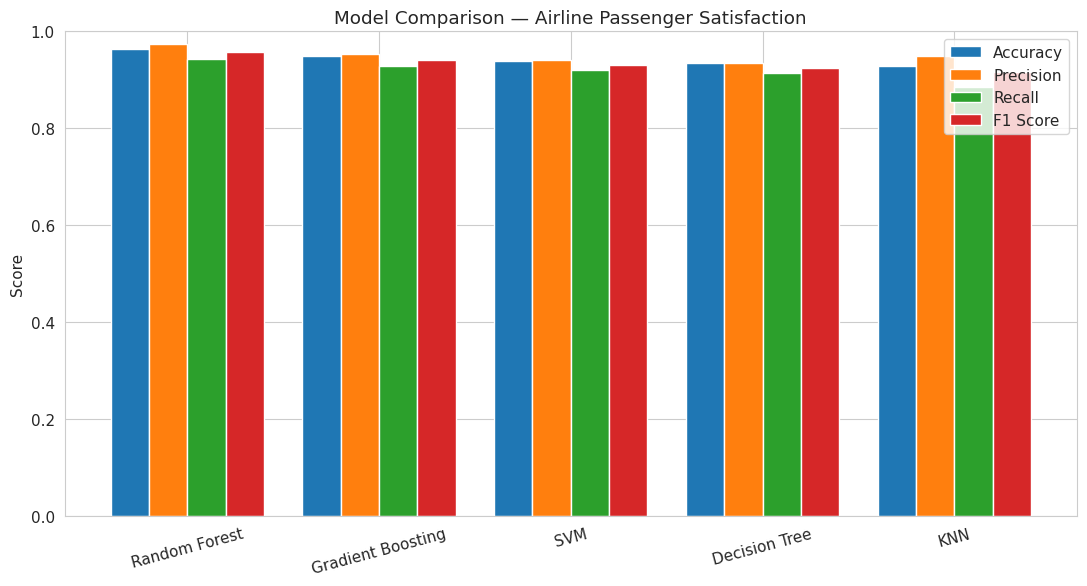

In [66]:
# Cell: Visualize model comparison
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(results_df))
width = 0.2

plt.figure(figsize=(11, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, results_df[metric], width, label=metric)

plt.xticks(x + width * 1.5, results_df["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Comparison — Airline Passenger Satisfaction")
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


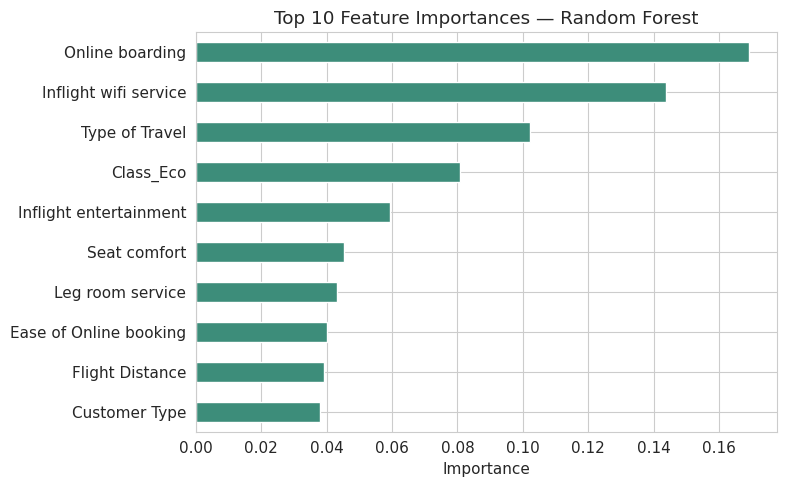

,0
Online boarding,0.169285
Inflight wifi service,0.143899
Type of Travel,0.102310
Class_Eco,0.080777
Inflight entertainment,0.059413
Seat comfort,0.045456
Leg room service,0.043030
Ease of Online booking,0.040264
Flight Distance,0.039231
Customer Type,0.038027


In [67]:
# Cell: Feature importance from Random Forest (top 10)
rf = trained_models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(10).sort_values().plot(kind="barh", color="#3D8D7A")
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(10)


## 5. Summary

- Best model by F1 Score: see the sorted comparison table above.
- `Online boarding`, `Type of Travel` (business vs. personal), `Class`, and `Inflight
  entertainment` are consistently the strongest predictors — matching the EDA findings
  (Business Class passengers are satisfied 69.4% of the time vs. ~19-25% for Eco/Eco Plus).
- Because this dataset came pre-split into train/test files, no `train_test_split()` was used
  to create the split — the provided split was respected as-is throughout the pipeline. A
  `train_test_split()` call was used only once, narrowly, to build SVM's training subsample.
- Missing `Arrival Delay in Minutes` values were filled using `Departure Delay in Minutes`
  (0.965 correlation) rather than a blind median fill — a targeted, justified imputation.
- SVM was trained on a stratified 8,000-row subsample (disclosed above) because RBF-kernel SVM
  does not scale to 100k+ rows in reasonable time — evaluation still used the full test set.
